# DeepFashion In-Shop Retrieval — Data Preparation

This notebook prepares the **DeepFashion In-Shop Clothes Retrieval** dataset for the Visual Product Search pipeline.

---

### Overview

The dataset comes with annotation files that tell us:
- Which images belong to train, query, or gallery splits
- Where the clothing item is located in each image (bounding box)

We read these files, combine them into a single structured table, run some checks, and save the result as CSV files that all downstream notebooks will use.

---

### What this notebook produces

| File | Description |
|------|-------------|
| `master_df.csv` | All 52,712 images with split label and bbox coordinates |
| `train.csv` | 25,882 images for CLIP fine-tuning |
| `query.csv` | 14,218 images used as search inputs during evaluation |
| `gallery.csv` | 12,612 images that form the searchable product database |

---

### Note on cropping

No image cropping is performed here. The bounding box coordinates are stored in the CSVs and passed to the YOLO notebook, which handles actual cropping. If YOLO cannot detect a clothing item in an image, the annotation bbox serves as a fallback crop.

## 1. Setup — Imports

In [1]:
import os
import json
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from PIL import Image

warnings.filterwarnings('ignore')
print('Libraries loaded.')

Libraries loaded.


## 2. Setup — Dataset Paths

The dataset was uploaded to Kaggle already extracted, so no unzipping is needed.
We just define where each file lives.

Expected folder layout:
```
dataset/
  img/
    MEN/   <- menswear images
    WOMEN/ <- womenswear images
  list_eval_partition.txt
  list_bbox_inshop.txt
  list_description_inshop.json
```

In [2]:
DATASET_ROOT = '/kaggle/input/datasets/akibatra25/fashionimagesearchdataset/dataset'
IMG_ROOT     = os.path.join(DATASET_ROOT, 'img')
PARTITION_FILE = os.path.join(DATASET_ROOT, 'list_eval_partition.txt')
BBOX_FILE      = os.path.join(DATASET_ROOT, 'list_bbox_inshop.txt')
DESC_FILE      = os.path.join(DATASET_ROOT, 'list_description_inshop.json')

SAVE_DIR = '/kaggle/working'

# Verify all required files are accessible
all_ok = True
for label, fpath in [('img folder', IMG_ROOT),
                     ('partition file', PARTITION_FILE),
                     ('bbox file', BBOX_FILE),
                     ('description file', DESC_FILE)]:
    ok = os.path.exists(fpath)
    print(f'[{"OK" if ok else "MISSING"}] {label}: {fpath}')
    if not ok:
        all_ok = False

print()
print('All paths verified.' if all_ok else 'WARNING: Some paths are missing!')

[OK] img folder: /kaggle/input/datasets/akibatra25/fashionimagesearchdataset/dataset/img
[OK] partition file: /kaggle/input/datasets/akibatra25/fashionimagesearchdataset/dataset/list_eval_partition.txt
[OK] bbox file: /kaggle/input/datasets/akibatra25/fashionimagesearchdataset/dataset/list_bbox_inshop.txt
[OK] description file: /kaggle/input/datasets/akibatra25/fashionimagesearchdataset/dataset/list_description_inshop.json

All paths verified.


## 3. Load Evaluation Partition

`list_eval_partition.txt` assigns each image to one of three roles:

| Split | Role |
|-------|------|
| train | Fine-tune CLIP on these images |
| query | These are the search inputs at evaluation time |
| gallery | The product database — we search through these |

Each line in the file looks like:
```
img/WOMEN/Dresses/id_00000002/02_1_front.jpg    id_00000002    train
```

In [3]:
with open(PARTITION_FILE, 'r') as f:
    raw_lines = f.readlines()

total_declared = int(raw_lines[0].strip())
print(f'Images declared in file : {total_declared}')
print(f'Column header           : {raw_lines[1].strip()}')
print(f'First data row          : {raw_lines[2].strip()}')
print()

partition_rows = []
for line in raw_lines[2:]:
    tokens = line.strip().split()
    if len(tokens) == 3:
        partition_rows.append({
            'image_name' : tokens[0],
            'item_id'    : tokens[1],
            'split'      : tokens[2]
        })

df_partition = pd.DataFrame(partition_rows)

print(f'Rows loaded: {len(df_partition)}')
print(f'Unique items: {df_partition["item_id"].nunique()}')
print()
print('Images per split:')
print(df_partition['split'].value_counts().to_string())

df_partition.head()

Images declared in file : 52712
Column header           : image_name item_id evaluation_status
First data row          : img/WOMEN/Dresses/id_00000002/02_1_front.jpg                           id_00000002 train

Rows loaded: 52712
Unique items: 7982

Images per split:
split
train      25882
query      14218
gallery    12612


,image_name,item_id,split
0,img/WOMEN/Dresses/id_00000002/02_1_front.jpg,id_00000002,train
1,img/WOMEN/Dresses/id_00000002/02_2_side.jpg,id_00000002,train
2,img/WOMEN/Dresses/id_00000002/02_4_full.jpg,id_00000002,train
3,img/WOMEN/Dresses/id_00000002/02_7_additional.jpg,id_00000002,train
4,img/WOMEN/Skirts/id_00000003/02_1_front.jpg,id_00000003,train


## 4. Load Bounding Box Annotations

`list_bbox_inshop.txt` gives us the location of the clothing item in each image as a rectangle defined by four coordinates.

Each line format:
```
image_name  clothes_type  pose_type  x1  y1  x2  y2
```

**Clothes type codes:**
- 1 = Upper body (shirts, jackets, tops)
- 2 = Lower body (trousers, skirts)
- 3 = Full body (dresses, jumpsuits)

**Pose type codes:**
- 1 = Frontal view
- 2 = Side view
- 3 = Back view
- 4 = Zoom out
- 5 = Zoom in
- 6 = Standalone (no model)

In [4]:
with open(BBOX_FILE, 'r') as f:
    bbox_lines = f.readlines()

print(f'Total bbox records : {bbox_lines[0].strip()}')
print(f'Header             : {bbox_lines[1].strip()}')
print(f'Sample entry       : {bbox_lines[2].strip()}')
print()

bbox_rows = []
for line in bbox_lines[2:]:
    tokens = line.strip().split()
    if len(tokens) == 7:
        bbox_rows.append({
            'image_name'   : tokens[0],
            'clothes_type' : int(tokens[1]),
            'pose_type'    : int(tokens[2]),
            'x1' : int(tokens[3]),
            'y1' : int(tokens[4]),
            'x2' : int(tokens[5]),
            'y2' : int(tokens[6])
        })

df_bbox = pd.DataFrame(bbox_rows)
print(f'Rows loaded: {len(df_bbox)}')

print('\nClothes type breakdown (1=upper, 2=lower, 3=full body):')
print(df_bbox['clothes_type'].value_counts().sort_index().to_string())

print('\nPose type breakdown (1=front, 2=side, 3=back, 4=zoom-out, 5=zoom-in, 6=standalone):')
print(df_bbox['pose_type'].value_counts().sort_index().to_string())

df_bbox.head()

Total bbox records : 52712
Header             : image_name clothes_type pose_type x_1 y_1 x_2 y_2
Sample entry       : img/WOMEN/Blouses_Shirts/id_00000001/02_1_front.jpg                    1 1 050 049 208 235

Rows loaded: 52712

Clothes type breakdown (1=upper, 2=lower, 3=full body):
clothes_type
1    33487
2    10494
3     8731

Pose type breakdown (1=front, 2=side, 3=back, 4=zoom-out, 5=zoom-in, 6=standalone):
pose_type
1    12861
2    10923
3    10661
4     6670
5    10914
6      683


,image_name,clothes_type,pose_type,x1,y1,x2,y2
0,img/WOMEN/Blouses_Shirts/id_00000001/02_1_fron...,1,1,50,49,208,235
1,img/WOMEN/Blouses_Shirts/id_00000001/02_2_side...,1,2,119,48,136,234
2,img/WOMEN/Blouses_Shirts/id_00000001/02_3_back...,1,3,50,42,213,240
3,img/WOMEN/Blouses_Shirts/id_00000001/02_4_full...,1,4,82,30,162,129
4,img/WOMEN/Dresses/id_00000002/02_1_front.jpg,3,1,65,45,233,252


## 5. Build Master Table

We merge the partition table and the bbox table on `image_name`.
The result is a single dataframe where each row represents one image
and contains all the information we need — its split, item ID, and bounding box.

In [5]:
df_all = df_partition.merge(df_bbox, on='image_name', how='left')

print(f'Shape after merge      : {df_all.shape}')
print(f'Rows with missing bbox : {df_all["x1"].isna().sum()}')

n_before = len(df_all)
df_all.dropna(subset=['x1', 'y1', 'x2', 'y2'], inplace=True)
df_all.reset_index(drop=True, inplace=True)
print(f'Removed {n_before - len(df_all)} rows with no bbox')
print(f'Final row count        : {len(df_all)}')

for col in ['x1', 'y1', 'x2', 'y2', 'clothes_type', 'pose_type']:
    df_all[col] = df_all[col].astype(int)

print('\nColumn overview:')
print(df_all.dtypes)
print()
df_all.head(8)

Shape after merge      : (52712, 9)
Rows with missing bbox : 0
Removed 0 rows with no bbox
Final row count        : 52712

Column overview:
image_name      object
item_id         object
split           object
clothes_type     int64
pose_type        int64
x1               int64
y1               int64
x2               int64
y2               int64
dtype: object



,image_name,item_id,split,clothes_type,pose_type,x1,y1,x2,y2
0,img/WOMEN/Dresses/id_00000002/02_1_front.jpg,id_00000002,train,3,1,65,45,233,252
1,img/WOMEN/Dresses/id_00000002/02_2_side.jpg,id_00000002,train,3,2,112,41,168,247
2,img/WOMEN/Dresses/id_00000002/02_4_full.jpg,id_00000002,train,3,4,89,34,169,167
3,img/WOMEN/Dresses/id_00000002/02_7_additional.jpg,id_00000002,train,3,5,73,40,194,251
4,img/WOMEN/Skirts/id_00000003/02_1_front.jpg,id_00000003,train,2,1,51,122,160,210
5,img/WOMEN/Skirts/id_00000003/02_2_side.jpg,id_00000003,train,2,2,121,13,131,112
6,img/WOMEN/Skirts/id_00000003/02_3_back.jpg,id_00000003,train,2,3,41,30,227,180
7,img/WOMEN/Skirts/id_00000003/02_4_full.jpg,id_00000003,train,2,4,116,87,201,151


## 6. Check Image Accessibility

Image paths in the annotation files look like `img/MEN/Denim/id_00000080/02_1_front.jpg`.
Since `IMG_ROOT` already points to the `img/` folder, we strip the `img/` prefix
when constructing full disk paths.

In [6]:
def resolve_path(img_name):
    """Turn an annotation image_name into its full path on disk."""
    # Strip leading 'img/' since IMG_ROOT already ends at that folder
    suffix = img_name[4:] if img_name.startswith('img/') else img_name
    return os.path.join(IMG_ROOT, suffix)

# Test on a handful of images
print('Path check on first 5 entries:')
for name in df_all['image_name'].head(5):
    p = resolve_path(name)
    print(f'  [{"OK" if os.path.exists(p) else "MISSING"}]  {p}')

# Random sample of 200
random_sample = df_all['image_name'].sample(200, random_state=99)
n_missing = sum(1 for n in random_sample if not os.path.exists(resolve_path(n)))
print(f'\nRandom spot check (200 images) — missing: {n_missing}')

Path check on first 5 entries:
  [OK]  /kaggle/input/datasets/akibatra25/fashionimagesearchdataset/dataset/img/WOMEN/Dresses/id_00000002/02_1_front.jpg
  [OK]  /kaggle/input/datasets/akibatra25/fashionimagesearchdataset/dataset/img/WOMEN/Dresses/id_00000002/02_2_side.jpg
  [OK]  /kaggle/input/datasets/akibatra25/fashionimagesearchdataset/dataset/img/WOMEN/Dresses/id_00000002/02_4_full.jpg
  [OK]  /kaggle/input/datasets/akibatra25/fashionimagesearchdataset/dataset/img/WOMEN/Dresses/id_00000002/02_7_additional.jpg
  [OK]  /kaggle/input/datasets/akibatra25/fashionimagesearchdataset/dataset/img/WOMEN/Skirts/id_00000003/02_1_front.jpg

Random spot check (200 images) — missing: 0


## 7. Visualise Annotation Bounding Boxes

Before saving, we visually inspect that the bounding boxes from the annotation file
correctly surround the clothing item in each image.

These rectangles are drawn on the original images purely for verification.
The actual cropping pipeline uses YOLO in the next notebook.

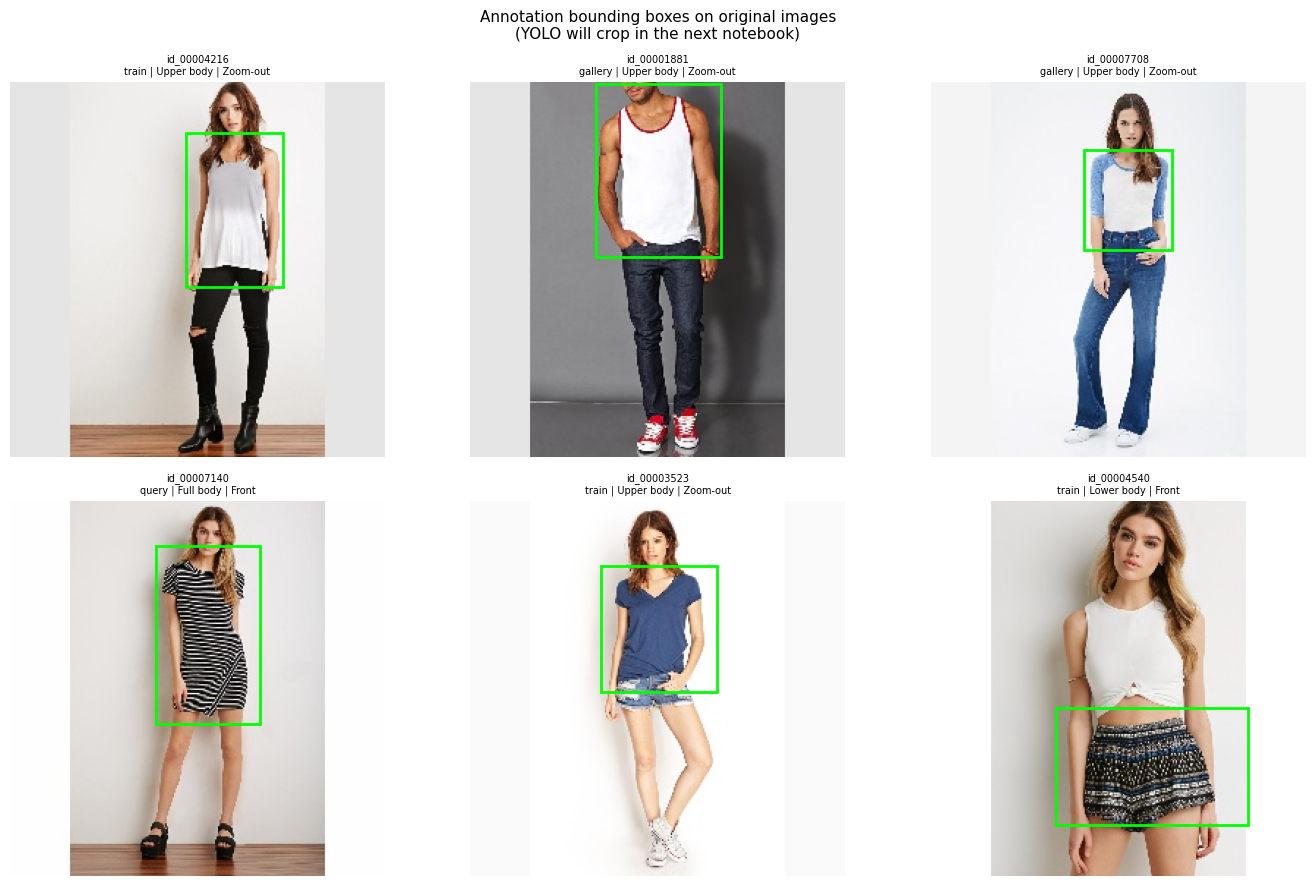

In [7]:
CLOTHES_LABELS = {1: 'Upper body', 2: 'Lower body', 3: 'Full body'}
POSE_LABELS    = {1: 'Front', 2: 'Side', 3: 'Back', 4: 'Zoom-out', 5: 'Zoom-in', 6: 'Standalone'}

sample_rows = df_all.sample(6, random_state=21)

fig, axes = plt.subplots(2, 3, figsize=(14, 9))
fig.suptitle(
    'Annotation bounding boxes on original images\n(YOLO will crop in the next notebook)',
    fontsize=11
)
axes = axes.flatten()

for ax, (_, row) in zip(axes, sample_rows.iterrows()):
    img_path = resolve_path(row['image_name'])
    if not os.path.exists(img_path):
        ax.axis('off')
        continue

    img = Image.open(img_path).convert('RGB')
    ax.imshow(img)

    # Draw bounding box
    x1, y1, x2, y2 = row['x1'], row['y1'], row['x2'], row['y2']
    box = patches.Rectangle(
        (x1, y1), x2 - x1, y2 - y1,
        linewidth=2, edgecolor='lime', facecolor='none'
    )
    ax.add_patch(box)

    c_label = CLOTHES_LABELS.get(row['clothes_type'], '?')
    p_label = POSE_LABELS.get(row['pose_type'], '?')
    ax.set_title(f"{row['item_id']}\n{row['split']} | {c_label} | {p_label}", fontsize=7)
    ax.axis('off')

plt.tight_layout()
plt.show()

## 8. Training Pair Analysis

CLIP fine-tuning uses contrastive learning — it requires at least 2 images of the same item
to form a positive pair. Items with only a single image in the train split cannot be used
and will be filtered out during fine-tuning.

Here we check how many usable pairs we have.

Training split — images per item ID
----------------------------------------
Total train images          : 25,882
Unique item IDs             : 3,997
Mean images per item        : 6.48
Min / Max                   : 1 / 162
Items usable for training   : 3,985  (2+ images)
Items excluded from training: 12  (only 1 image)


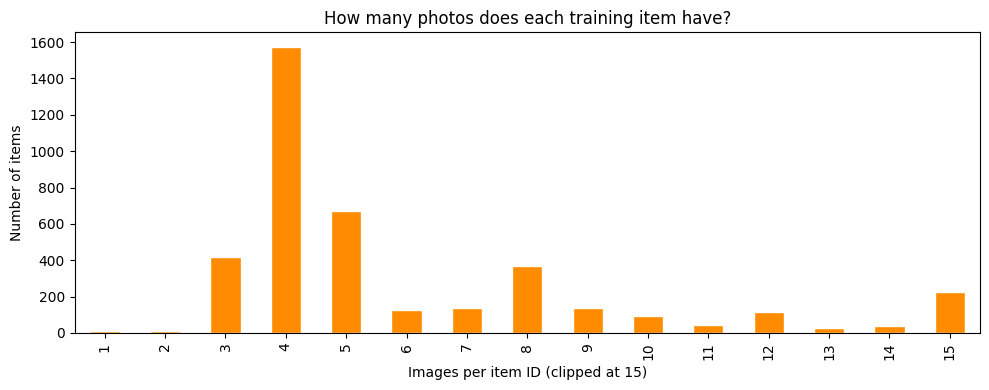

In [8]:
df_train_only = df_all[df_all['split'] == 'train']
imgs_per_item = df_train_only.groupby('item_id').size()

print('Training split — images per item ID')
print('-' * 40)
print(f'Total train images          : {len(df_train_only):,}')
print(f'Unique item IDs             : {imgs_per_item.shape[0]:,}')
print(f'Mean images per item        : {imgs_per_item.mean():.2f}')
print(f'Min / Max                   : {imgs_per_item.min()} / {imgs_per_item.max()}')
print(f'Items usable for training   : {(imgs_per_item >= 2).sum():,}  (2+ images)')
print(f'Items excluded from training: {(imgs_per_item == 1).sum():,}  (only 1 image)')

fig, ax = plt.subplots(figsize=(10, 4))
imgs_per_item.clip(upper=15).value_counts().sort_index().plot(
    kind='bar', ax=ax, color='darkorange', edgecolor='white'
)
ax.set_xlabel('Images per item ID (clipped at 15)')
ax.set_ylabel('Number of items')
ax.set_title('How many photos does each training item have?')
plt.tight_layout()
plt.show()

## 9. Save CSV Files

We save four CSV files to `/kaggle/working/`.
These are the only outputs of this notebook and must be saved as a Kaggle dataset
so that all subsequent notebooks can access them.

Each file contains these columns:
`image_name, item_id, split, clothes_type, pose_type, x1, y1, x2, y2`

In [9]:
df_all.to_csv(os.path.join(SAVE_DIR, 'master_df.csv'), index=False)

splits = {}
for name in ['train', 'query', 'gallery']:
    splits[name] = df_all[df_all['split'] == name].reset_index(drop=True)
    splits[name].to_csv(os.path.join(SAVE_DIR, f'{name}.csv'), index=False)

print('CSV files saved successfully.')
print()
print(f'{"File":<20} {"Rows":>8}')
print('-' * 30)
print(f'{"master_df.csv":<20} {len(df_all):>8,}')
for name, df_ in splits.items():
    print(f'{name + ".csv":<20} {len(df_):>8,}')

print()
print('Files in /kaggle/working:')
for fname in sorted(os.listdir(SAVE_DIR)):
    fpath = os.path.join(SAVE_DIR, fname)
    if os.path.isfile(fpath):
        print(f'  {fname}  ({os.path.getsize(fpath):,} bytes)')

CSV files saved successfully.

File                     Rows
------------------------------
master_df.csv          52,712
train.csv              25,882
query.csv              14,218
gallery.csv            12,612

Files in /kaggle/working:
  __notebook__.ipynb  (837,907 bytes)
  gallery.csv  (1,077,075 bytes)
  master_df.csv  (4,458,315 bytes)
  query.csv  (1,202,804 bytes)
  train.csv  (2,178,556 bytes)


## 10. Summary

In [10]:
print('=' * 55)
print('            DATA PREPARATION COMPLETE')
print('=' * 55)
print(f'  Total images        : {len(df_all):,}')
print(f'  Train               : {len(splits["train"]):,}')
print(f'  Query               : {len(splits["query"]):,}')
print(f'  Gallery             : {len(splits["gallery"]):,}')
print(f'  Unique item IDs     : {df_all["item_id"].nunique():,}')
print()
print('  Saved to /kaggle/working/')
print('    master_df.csv, train.csv, query.csv, gallery.csv')
print()
print('  No image crops produced in this notebook.')
print('  --> Next: YOLO detection and cropping notebook')
print('=' * 55)

            DATA PREPARATION COMPLETE
  Total images        : 52,712
  Train               : 25,882
  Query               : 14,218
  Gallery             : 12,612
  Unique item IDs     : 7,982

  Saved to /kaggle/working/
    master_df.csv, train.csv, query.csv, gallery.csv

  No image crops produced in this notebook.
  --> Next: YOLO detection and cropping notebook
